# 03 — VQE at a Single Point

Build the two-qubit ansatz, run VQE with a noise-free statevector estimator at a few representative detunings, and compare optimizers on the same problem instance.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd

from qiskit_algorithms.optimizers import COBYLA, NELDER_MEAD, L_BFGS_B, SPSA

from src.hamiltonian import bragg_hamiltonian
from src.encoding import padded_bragg_hamiltonian, pauli_decompose
from src.exact_solver import ground_state
from src.vqe_solver import make_ansatz, run_vqe

## Ansatz circuit

A hardware-efficient two-qubit ansatz: one RY layer, a single CX, and a second RY layer.

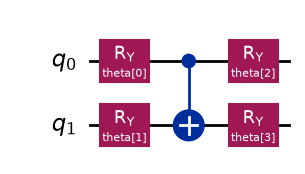

In [2]:
ansatz = make_ansatz()
fig_ansatz = ansatz.draw("mpl")
fig_ansatz.savefig("../figures/ansatz_circuit.png", dpi=150, bbox_inches="tight")
fig_ansatz

## VQE at three detunings

In [3]:
deltas = [-8.0, 0.0, 8.0]
omega, penalty = 0.5, 13.0

for delta in deltas:
    print(f"\n--- delta = {delta} ---")

    H_matrix = padded_bragg_hamiltonian(delta, omega, penalty)
    H_pauli = pauli_decompose(H_matrix)
    print("Pauli decomposition correct:", np.allclose(H_pauli.to_matrix(), H_matrix))

    result, vqe_state = run_vqe(H_pauli)
    vqe_energy = np.real(result.eigenvalue)

    exact_energy, exact_state_3d = ground_state(delta, omega)
    exact_state_4d = np.array([*exact_state_3d, 0.0], dtype=complex)

    energy_error = abs(vqe_energy - exact_energy)
    fidelity = abs(np.vdot(exact_state_4d, vqe_state)) ** 2
    populations = np.abs(vqe_state) ** 2

    print("energy error:", energy_error)
    print("fidelity:", fidelity)
    print("VQE populations |00>,|01>,|10>,|11>:", populations)


--- delta = -8.0 ---
Pauli decomposition correct: True


energy error: 8.323393956288783e-07
fidelity: 0.9999999497021166
VQE populations |00>,|01>,|10>,|11>: [9.84935465e-01 1.50493888e-02 1.51024717e-05 4.41727555e-08]

--- delta = 0.0 ---
Pauli decomposition correct: True


energy error: 6.851159375931282e-09
fidelity: 0.9999999994333215
VQE populations |00>,|01>,|10>,|11>: [1.42965140e-02 9.71404259e-01 1.42992266e-02 5.01735322e-10]

--- delta = 8.0 ---
Pauli decomposition correct: True


energy error: 1.3977329338388245e-07
fidelity: 0.9999999733096998
VQE populations |00>,|01>,|10>,|11>: [1.47596471e-05 1.50779542e-02 9.84907284e-01 2.04715424e-09]


## Optimizer comparison

Compare optimizers on the same Hamiltonian and initial point, near the $\delta=4$ avoided crossing.

In [4]:
delta_bench, omega_bench, penalty_bench = 4.0, 0.5, 13.0

H_bench = pauli_decompose(padded_bragg_hamiltonian(delta_bench, omega_bench, penalty_bench))
exact_bench_energy, exact_bench_vector = ground_state(delta_bench, omega_bench)
exact_bench_state_4d = np.array([*exact_bench_vector, 0.0], dtype=complex)

rng = np.random.default_rng(42)
shared_initial_point = 2 * np.pi * rng.random(4)

optimizer_configs = {
    "COBYLA": COBYLA(maxiter=500),
    "Nelder-Mead": NELDER_MEAD(maxiter=500),
    "L-BFGS-B": L_BFGS_B(maxiter=500),
    "SPSA": SPSA(maxiter=200),
}

optimizer_rows = []
for name, optimizer in optimizer_configs.items():
    start = time.perf_counter()
    result, vqe_state = run_vqe(H_bench, optimizer=optimizer, initial_point=shared_initial_point.copy())
    elapsed = time.perf_counter() - start

    vqe_energy = np.real(result.eigenvalue)
    fidelity = abs(np.vdot(exact_bench_state_4d, vqe_state)) ** 2

    optimizer_rows.append({
        "optimizer": name,
        "final_energy": vqe_energy,
        "energy_error": abs(vqe_energy - exact_bench_energy),
        "fidelity": fidelity,
        "function_evals": result.cost_function_evals,
        "time_s": elapsed,
    })

optimizer_table = pd.DataFrame(optimizer_rows)
optimizer_table

C:\Users\aarya\PycharmProjects\Qiskit\.venv\Lib\site-packages\qiskit_algorithms\optimizers\scipy_optimizer.py:162: OptimizeWarning: Unknown solver options: iprint
  raw_result = minimize(


,optimizer,final_energy,energy_error,fidelity,function_evals,time_s
0,COBYLA,-0.514895,3.530982e-07,1.000000,170,0.639665
1,Nelder-Mead,-0.514896,6.169804e-10,1.000000,164,0.249210
2,L-BFGS-B,-0.514896,1.251221e-13,1.000000,60,0.109040
3,SPSA,-0.512820,2.075126e-03,0.997942,400,0.705667
